 # Narrative Features Analysis — Monetary Relief Prediction
 **v2**: 26 features, time-based train/test split

In [ ]:
import re
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import QuantileTransformer

CSV_PATH      = "complaints-2026-05-19_22_40.csv"
NARRATIVE_COL = "Consumer complaint narrative"
TARGET_COL    = "Company response to consumer"
DATE_COL      = "Date received"

In [ ]:
df = pd.read_csv(CSV_PATH, on_bad_lines='skip', low_memory=False)
df["label"] = (df[TARGET_COL] == "Closed with monetary relief").astype(int)
df = df.dropna(subset=[NARRATIVE_COL]).reset_index(drop=True)
df["date"] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
narr = df[NARRATIVE_COL]

print(f"Rows: {len(df):,}  |  Positive rate: {df['label'].mean():.2%}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

Rows: 177,339  |  Positive rate: 14.94%
Date range: 2017-04-24 → 2026-04-29


In [ ]:
def plot_dist(col, title, spearman_r, clip_pct=99):
    data0 = df.loc[df["label"] == 0, col].dropna()
    data1 = df.loc[df["label"] == 1, col].dropna()
    clip_val = df[col].quantile(clip_pct / 100)
    d0 = data0.clip(upper=clip_val)
    d1 = data1.clip(upper=clip_val)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{title}   |   Spearman r = {spearman_r:+.4f}", fontsize=12, fontweight="bold")

    ax = axes[0]
    ax.hist(d0, bins=60, density=True, alpha=0.5, color="#2563eb",
            label=f"No relief  (median={d0.median():.2f})")
    ax.hist(d1, bins=60, density=True, alpha=0.5, color="#dc2626",
            label=f"Monetary relief  (median={d1.median():.2f})")
    ax.axvline(d0.median(), color="#2563eb", lw=1.5, linestyle="--")
    ax.axvline(d1.median(), color="#dc2626", lw=1.5, linestyle="--")
    ax.set_xlabel(col); ax.set_ylabel("Density")
    ax.set_title(f"Histogram (clipped at {clip_pct}th pct)")
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.boxplot([d0, d1], labels=["No relief (0)", "Monetary relief (1)"],
               patch_artist=True,
               boxprops=dict(facecolor="#e0e7ff"),
               medianprops=dict(color="black", lw=2))
    ax.set_ylabel(col); ax.set_title("Boxplot by label")
    plt.tight_layout(); plt.show()

def spearman_report(col, label):
    mask = df[col].notna()
    r, p = spearmanr(df.loc[mask, col], df.loc[mask, "label"])
    print(f"{col:35s}  r={r:+.4f}  p={p:.2e}")
    print(f"  → {label}")
    return r

dollar_count                         r=+0.1793  p=0.00e+00
  → # of '$XXX' mentions — specificity of financial claim


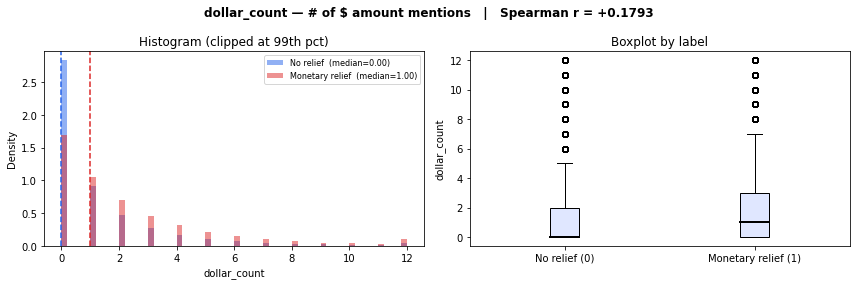

In [ ]:
df["dollar_count"] = narr.str.count(r'\$[\d,]+')
r = spearman_report("dollar_count", "# of '$XXX' mentions — specificity of financial claim")
plot_dist("dollar_count", "dollar_count — # of $ amount mentions", r)

sentence_count                       r=+0.1196  p=0.00e+00
  → # of sentences — more sentences = more structured complaint


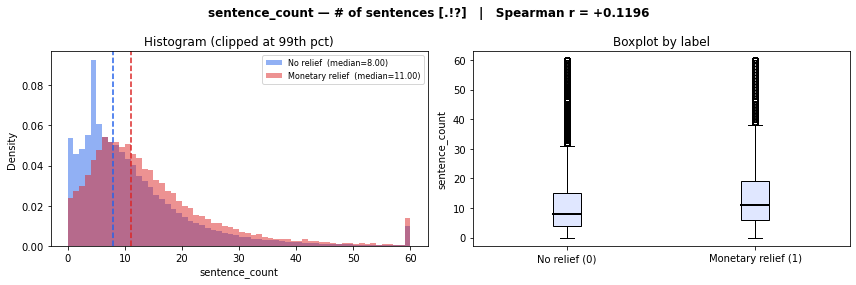

In [ ]:
df["sentence_count"] = narr.str.count(r'[.!?]+')
r = spearman_report("sentence_count", "# of sentences — more sentences = more structured complaint")
plot_dist("sentence_count", "sentence_count — # of sentences [.!?]", r)

lexical_diversity                    r=-0.1040  p=0.00e+00
  → unique words ÷ total words — lower = more repetitive, focused language wins


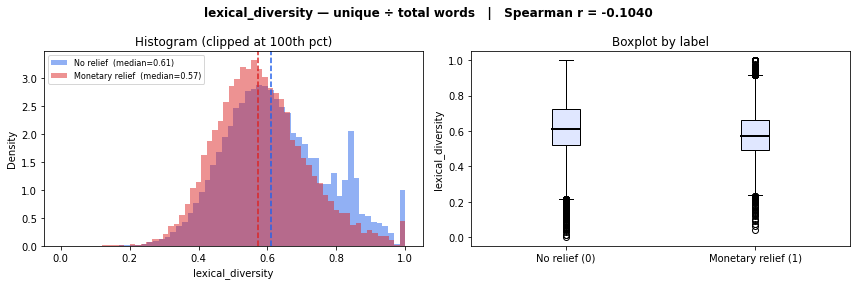

In [ ]:
df["lexical_diversity"] = narr.apply(
    lambda t: len(set(t.lower().split())) / len(t.split()) if t.split() else 0
)
r = spearman_report("lexical_diversity", "unique words ÷ total words — lower = more repetitive, focused language wins")
plot_dist("lexical_diversity", "lexical_diversity — unique ÷ total words", r, clip_pct=100)

word_count                           r=+0.0964  p=0.00e+00
  → Total words — longer complaints get more relief


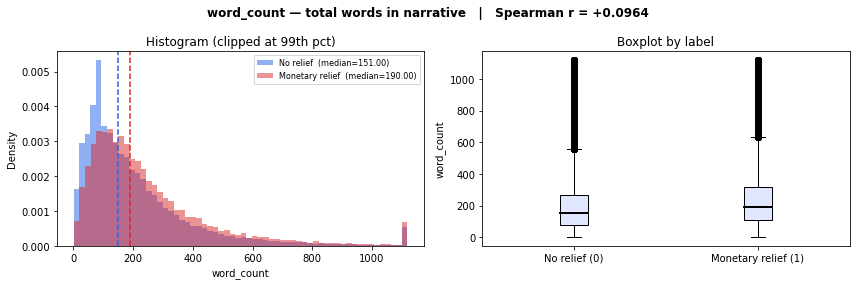

In [ ]:
df["word_count"] = narr.str.split().str.len()
r = spearman_report("word_count", "Total words — longer complaints get more relief")
plot_dist("word_count", "word_count — total words in narrative", r)

char_len                             r=+0.0924  p=0.00e+00
  → Total characters — highly correlated with word_count


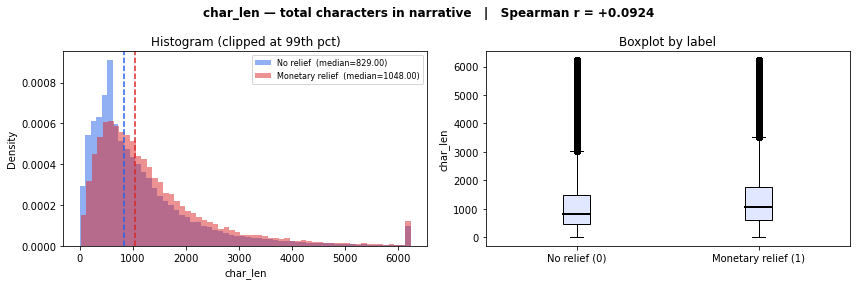

In [ ]:
df["char_len"] = narr.str.len()
r = spearman_report("char_len", "Total characters — highly correlated with word_count")
plot_dist("char_len", "char_len — total characters in narrative", r)

Computing Flesch-Kincaid... (~30s)
flesch_kincaid                       r=+0.0827  p=9.25e-267
  → Readability score — higher = easier to read; simpler writing wins


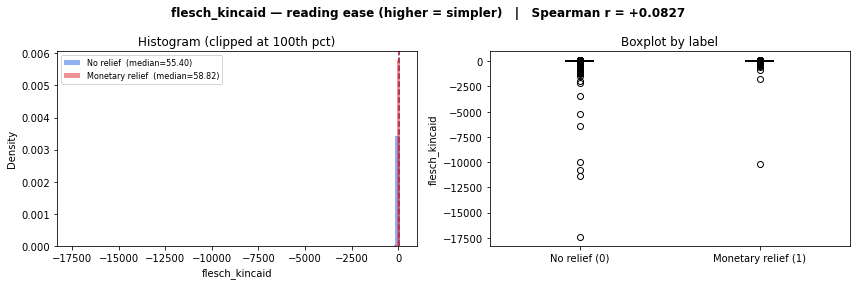

In [ ]:
def count_syllables(word):
    return max(1, len(re.findall(r'[aeiouy]+', word.lower().strip(".,!?;:'\""))))

def flesch_reading_ease(text):
    words = text.split()
    if not words:
        return np.nan
    sentences = max(1, len(re.findall(r'[.!?]+', text)))
    syllables  = sum(count_syllables(w) for w in words)
    return 206.835 - 1.015 * (len(words) / sentences) - 84.6 * (syllables / len(words))

print("Computing Flesch-Kincaid... (~30s)")
df["flesch_kincaid"] = narr.apply(flesch_reading_ease)
r = spearman_report("flesch_kincaid", "Readability score — higher = easier to read; simpler writing wins")
plot_dist("flesch_kincaid", "flesch_kincaid — reading ease (higher = simpler)", r, clip_pct=100)

avg_sentence_len                     r=-0.0587  p=2.23e-128
  → Words per sentence — shorter sentences = more direct writing wins


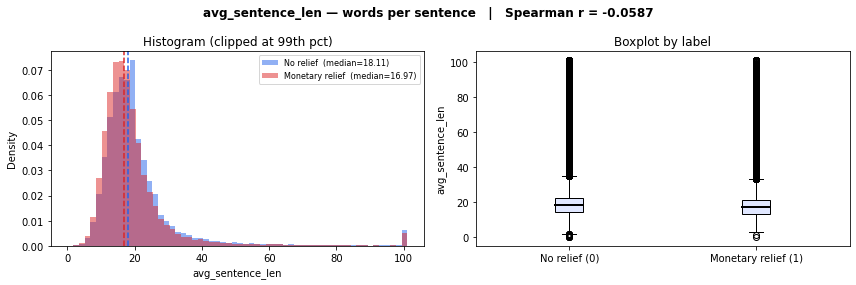

In [ ]:
df["avg_sentence_len"] = df["word_count"] / df["sentence_count"].replace(0, np.nan)
r = spearman_report("avg_sentence_len", "Words per sentence — shorter sentences = more direct writing wins")
plot_dist("avg_sentence_len", "avg_sentence_len — words per sentence", r)

date_count                           r=+0.0546  p=3.17e-117
  → # of date mentions — more dates = better documented timeline


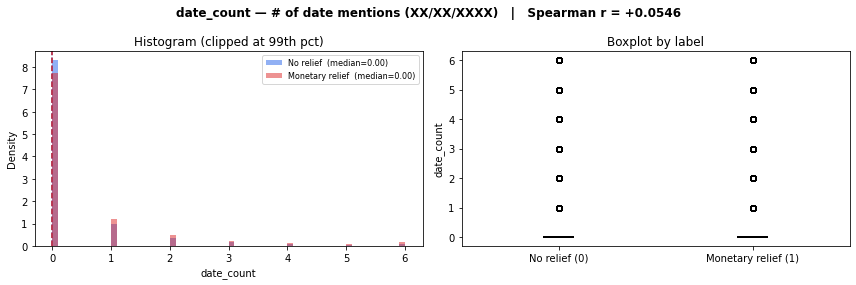

In [ ]:
df["date_count"] = narr.str.count(r'\b(?:XX|\d{1,2})/(?:XX|\d{1,2})/(?:XX|\d{2,4})\b')
r = spearman_report("date_count", "# of date mentions — more dates = better documented timeline")
plot_dist("date_count", "date_count — # of date mentions (XX/XX/XXXX)", r)

caps_ratio                           r=+0.0436  p=2.54e-75
  → Proportion of ALL-CAPS words — emphasis / mild frustration signal


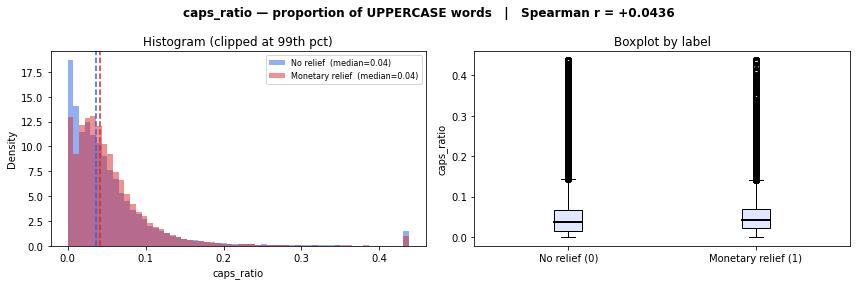

In [ ]:
df["caps_ratio"] = narr.apply(
    lambda t: sum(1 for w in t.split() if w.isupper() and len(w) > 1) / max(len(t.split()), 1)
)
r = spearman_report("caps_ratio", "Proportion of ALL-CAPS words — emphasis / mild frustration signal")
plot_dist("caps_ratio", "caps_ratio — proportion of UPPERCASE words", r)

avg_word_len                         r=-0.0235  p=3.98e-23
  → Avg chars per word — shorter words = simpler vocabulary wins


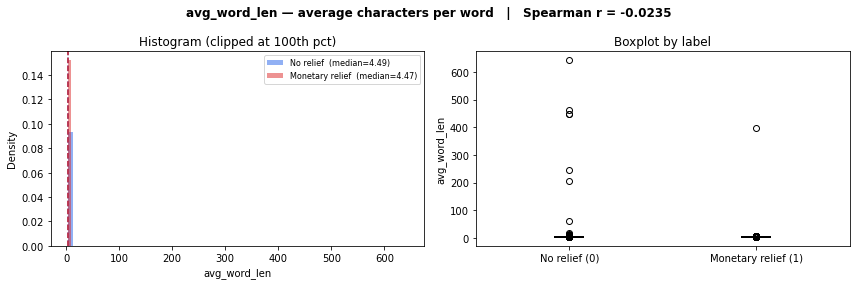

In [ ]:
df["avg_word_len"] = narr.apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0
)
r = spearman_report("avg_word_len", "Avg chars per word — shorter words = simpler vocabulary wins")
plot_dist("avg_word_len", "avg_word_len — average characters per word", r, clip_pct=100)

exclamation_count                    r=+0.0223  p=4.93e-21
  → # of '!' — emotional intensity; weakest signal


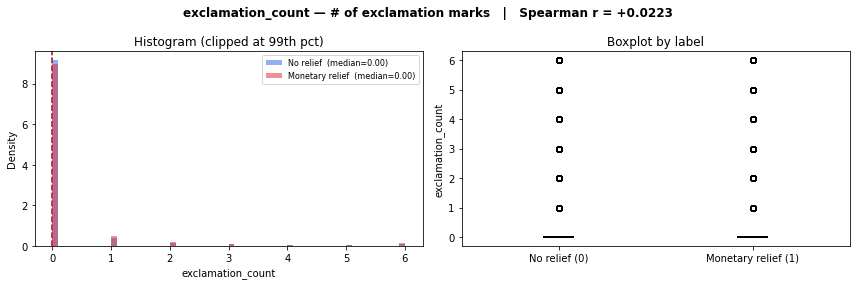

In [ ]:
df["exclamation_count"] = narr.str.count(r'!')
r = spearman_report("exclamation_count", "# of '!' — emotional intensity; weakest signal")
plot_dist("exclamation_count", "exclamation_count — # of exclamation marks", r)

account_ref_count                    r=+0.0963  p=0.00e+00
  → Masked account numbers (XXXX) + digit sequences — specificity signal


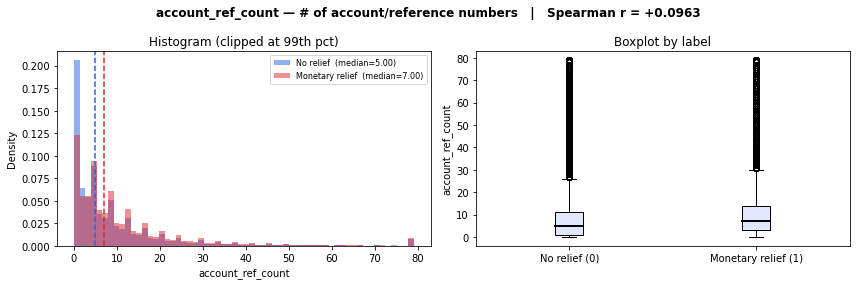

In [ ]:
df["account_ref_count"] = narr.str.count(r'\bX{4,}\b|\b\d{4,}\b')
r = spearman_report("account_ref_count", "Masked account numbers (XXXX) + digit sequences — specificity signal")
plot_dist("account_ref_count", "account_ref_count — # of account/reference numbers", r)

total_dollar_amount                  r=+0.1405  p=0.00e+00
  → Sum of all $ figures — higher financial stakes = more relief


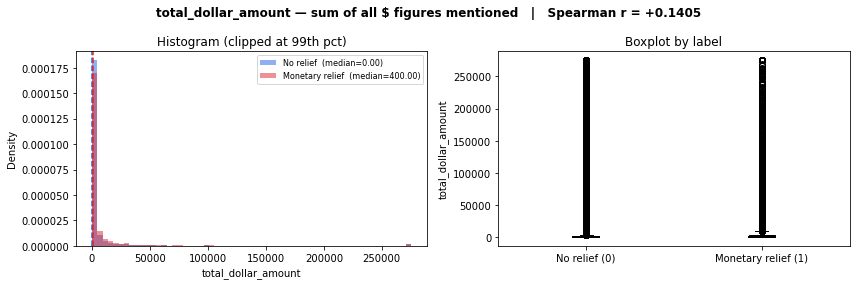

In [ ]:
def extract_dollar_amounts(text):
    amounts = []
    for m in re.findall(r'\$[\d,]+(?:\.\d+)?', text):
        try:
            amounts.append(float(m.replace('$', '').replace(',', '')))
        except ValueError:
            pass
    return amounts

dollar_series = narr.apply(extract_dollar_amounts)
df["total_dollar_amount"] = dollar_series.apply(lambda x: sum(x) if x else 0)
r = spearman_report("total_dollar_amount", "Sum of all $ figures — higher financial stakes = more relief")
plot_dist("total_dollar_amount", "total_dollar_amount — sum of all $ figures mentioned", r)

max_dollar_amount                    r=+0.1354  p=0.00e+00
  → Largest single $ figure — one big claim more compelling than many small ones


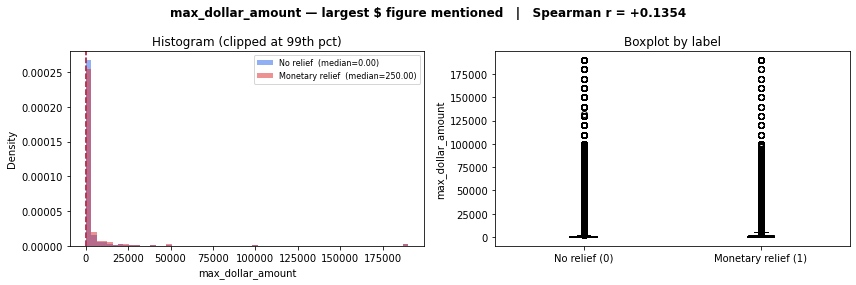

In [ ]:
df["max_dollar_amount"] = dollar_series.apply(lambda x: max(x) if x else 0)
r = spearman_report("max_dollar_amount", "Largest single $ figure — one big claim more compelling than many small ones")
plot_dist("max_dollar_amount", "max_dollar_amount — largest $ figure mentioned", r)

duration_mention_count               r=+0.1008  p=0.00e+00
  → Time words — documenting how long the problem persisted signals persistence


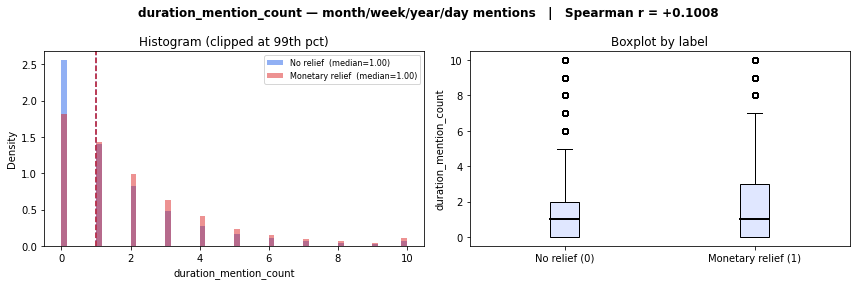

In [ ]:
df["duration_mention_count"] = narr.str.count(
    r'\b(month|months|week|weeks|year|years|day|days)\b', flags=re.IGNORECASE
)
r = spearman_report("duration_mention_count", "Time words — documenting how long the problem persisted signals persistence")
plot_dist("duration_mention_count", "duration_mention_count — month/week/year/day mentions", r)

contact_attempt_count                r=+0.0773  p=6.30e-233
  → Prior contact words — effort before filing signals a persistent complainant


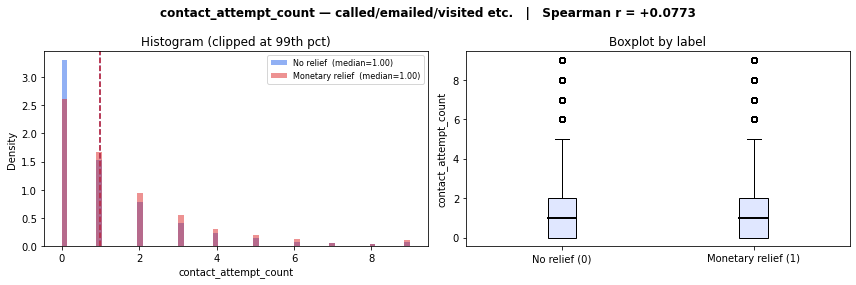

In [ ]:
df["contact_attempt_count"] = narr.str.count(
    r'\b(called|emailed|email|spoke with|spoken with|visited|wrote|contacted|reached out|called back|speaking with)\b',
    flags=re.IGNORECASE
)
r = spearman_report("contact_attempt_count", "Prior contact words — effort before filing signals a persistent complainant")
plot_dist("contact_attempt_count", "contact_attempt_count — called/emailed/visited etc.", r)

escalation_person_count              r=+0.0638  p=1.51e-159
  → Staff role words — naming who you spoke to signals escalation within company


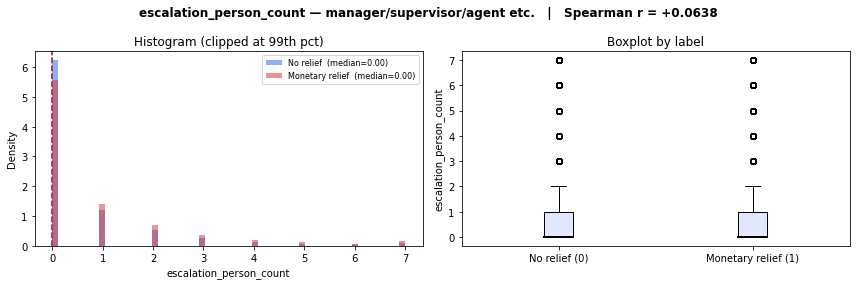

In [ ]:
df["escalation_person_count"] = narr.str.count(
    r'\b(representative|manager|supervisor|agent|customer service|customer care|specialist|officer)\b',
    flags=re.IGNORECASE
)
r = spearman_report("escalation_person_count", "Staff role words — naming who you spoke to signals escalation within company")
plot_dist("escalation_person_count", "escalation_person_count — manager/supervisor/agent etc.", r)

refund_count                         r=+0.0624  p=1.16e-152
  → Explicit refund/compensation words — clearly stating what you want correlates with getting it


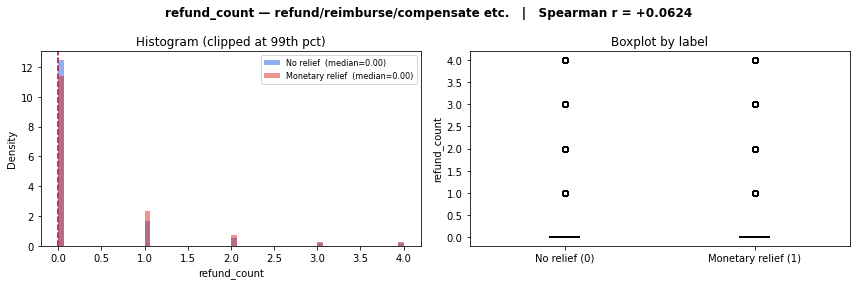

In [ ]:
df["refund_count"] = narr.str.count(
    r'\b(refund|reimburse|reimbursement|compensate|compensation|credit back|pay back|pay me back|money back)\b',
    flags=re.IGNORECASE
)
r = spearman_report("refund_count", "Explicit refund/compensation words — clearly stating what you want correlates with getting it")
plot_dist("refund_count", "refund_count — refund/reimburse/compensate etc.", r)

regulatory_count                     r=-0.0517  p=4.45e-105
  → Regulatory body mentions — NEGATIVE; may harden company stance or route complaint differently


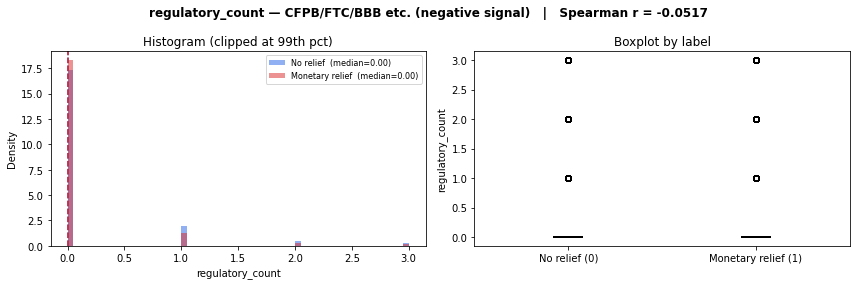

In [ ]:
df["regulatory_count"] = narr.str.count(
    r'\b(CFPB|FTC|BBB|attorney general|consumer protection|OCC|FDIC|federal reserve)\b',
    flags=re.IGNORECASE
)
r = spearman_report("regulatory_count", "Regulatory body mentions — NEGATIVE; may harden company stance or route complaint differently")
plot_dist("regulatory_count", "regulatory_count — CFPB/FTC/BBB etc. (negative signal)", r)

urgency_count                        r=+0.0432  p=5.49e-74
  → Urgency words — framing issue as time-sensitive slightly helps


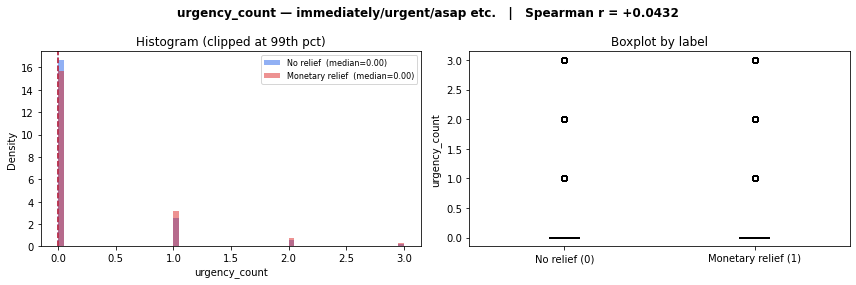

In [ ]:
df["urgency_count"] = narr.str.count(
    r'\b(immediately|urgent|urgently|asap|right away|as soon as possible|promptly|right now)\b',
    flags=re.IGNORECASE
)
r = spearman_report("urgency_count", "Urgency words — framing issue as time-sensitive slightly helps")
plot_dist("urgency_count", "urgency_count — immediately/urgent/asap etc.", r)

paragraph_count                      r=+0.0410  p=6.37e-67
  → # of paragraphs — organised multi-paragraph structure signals a prepared complainant


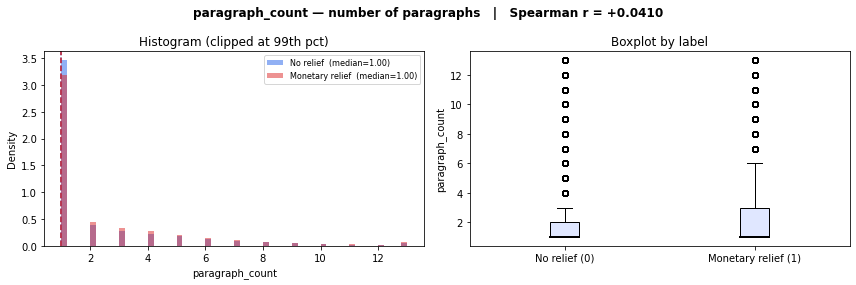

In [ ]:
df["paragraph_count"] = narr.str.count(r'\n\s*\n') + 1
r = spearman_report("paragraph_count", "# of paragraphs — organised multi-paragraph structure signals a prepared complainant")
plot_dist("paragraph_count", "paragraph_count — number of paragraphs", r)

police_fraud_count                   r=+0.0315  p=4.06e-40
  → Fraud/crime words — framing as criminal matter slightly helps


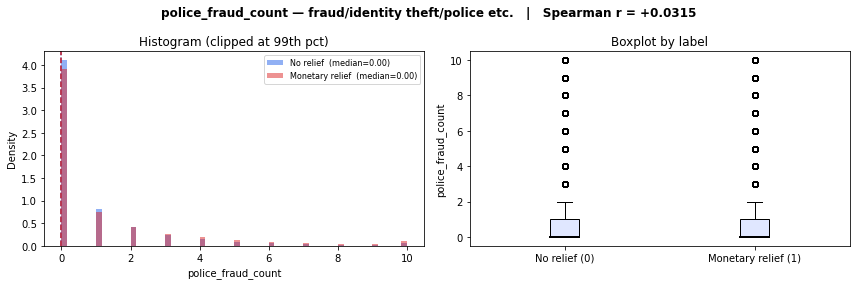

In [ ]:
df["police_fraud_count"] = narr.str.count(
    r'\b(police|filed a report|identity theft|fraud|fraudulent|stolen|theft)\b',
    flags=re.IGNORECASE
)
r = spearman_report("police_fraud_count", "Fraud/crime words — framing as criminal matter slightly helps")
plot_dist("police_fraud_count", "police_fraud_count — fraud/identity theft/police etc.", r)

quoted_speech_count                  r=+0.0229  p=4.50e-22
  → Quoted text — directly quoting a rep signals specificity and documentation


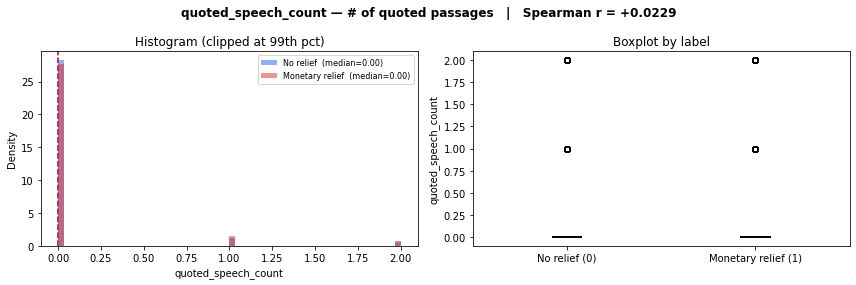

In [ ]:
df["quoted_speech_count"] = narr.str.count(r'"[^"]{3,}"')
r = spearman_report("quoted_speech_count", "Quoted text — directly quoting a rep signals specificity and documentation")
plot_dist("quoted_speech_count", "quoted_speech_count — # of quoted passages", r)

question_mark_count                  r=+0.0194  p=2.64e-16
  → # of '?' — asking rhetorical questions slightly correlates with relief


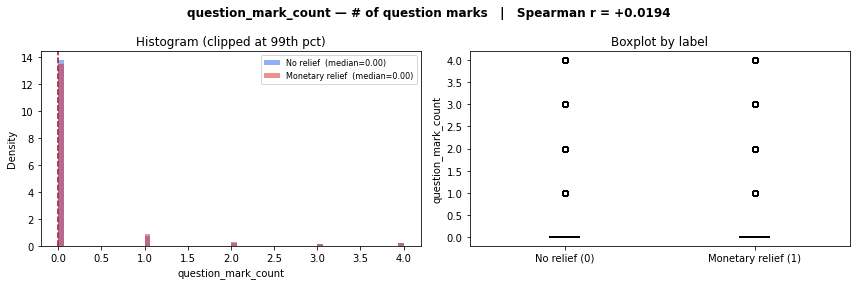

In [ ]:
df["question_mark_count"] = narr.str.count(r'\?')
r = spearman_report("question_mark_count", "# of '?' — asking rhetorical questions slightly correlates with relief")
plot_dist("question_mark_count", "question_mark_count — # of question marks", r)

negative_emotion_count               r=+0.0182  p=1.83e-14
  → Emotion words — weak positive; a little venting helps but not much


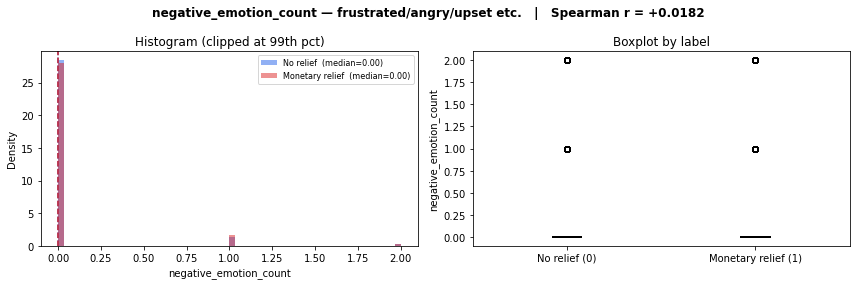

In [ ]:
df["negative_emotion_count"] = narr.str.count(
    r'\b(frustrated|frustrating|frustration|angry|anger|upset|disappointed|disappointment|shocked|outraged|furious|disgusted|distressed)\b',
    flags=re.IGNORECASE
)
r = spearman_report("negative_emotion_count", "Emotion words — weak positive; a little venting helps but not much")
plot_dist("negative_emotion_count", "negative_emotion_count — frustrated/angry/upset etc.", r)

legal_count                          r=-0.0164  p=4.46e-12
  → Legal threat words — NEGATIVE; threatening legal action slightly hurts outcomes


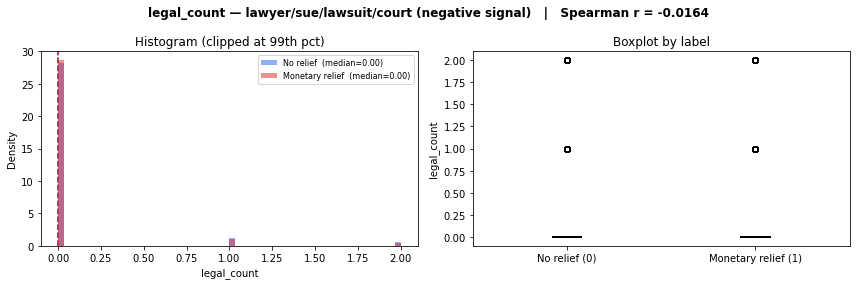

In [ ]:
df["legal_count"] = narr.str.count(
    r'\b(lawyer|attorney|sue|suing|lawsuit|court|legal action|arbitration)\b',
    flags=re.IGNORECASE
)
r = spearman_report("legal_count", "Legal threat words — NEGATIVE; threatening legal action slightly hurts outcomes")
plot_dist("legal_count", "legal_count — lawyer/sue/lawsuit/court (negative signal)", r)

In [ ]:
FEATURES = [
    "dollar_count", "sentence_count", "lexical_diversity", "word_count",
    "char_len", "flesch_kincaid", "avg_sentence_len", "date_count",
    "caps_ratio", "avg_word_len", "exclamation_count", "account_ref_count",
    "total_dollar_amount", "max_dollar_amount", "duration_mention_count",
    "contact_attempt_count", "escalation_person_count", "refund_count",
    "regulatory_count", "urgency_count", "paragraph_count",
    "police_fraud_count", "quoted_speech_count", "question_mark_count",
    "negative_emotion_count", "legal_count",
]
df[FEATURES] = df[FEATURES].fillna(0)

split_idx   = int(len(df) * 0.80)
cutoff_date = df["date"].iloc[split_idx]
train_df    = df.iloc[:split_idx]
test_df     = df.iloc[split_idx:]

print(f"Train: {len(train_df):,} rows  ({train_df['date'].min().date()} → {train_df['date'].max().date()})")
print(f"Test:  {len(test_df):,}  rows  ({test_df['date'].min().date()} → {test_df['date'].max().date()})")
print(f"Cutoff date:         {cutoff_date.date()}")
print(f"Train positive rate: {train_df['label'].mean():.2%}")
print(f"Test  positive rate: {test_df['label'].mean():.2%}")

Train: 141,871 rows  (2017-04-24 → 2025-05-21)
Test:  35,468  rows  (2025-05-21 → 2026-04-29)
Cutoff date:         2025-05-21
Train positive rate: 15.51%
Test  positive rate: 12.65%


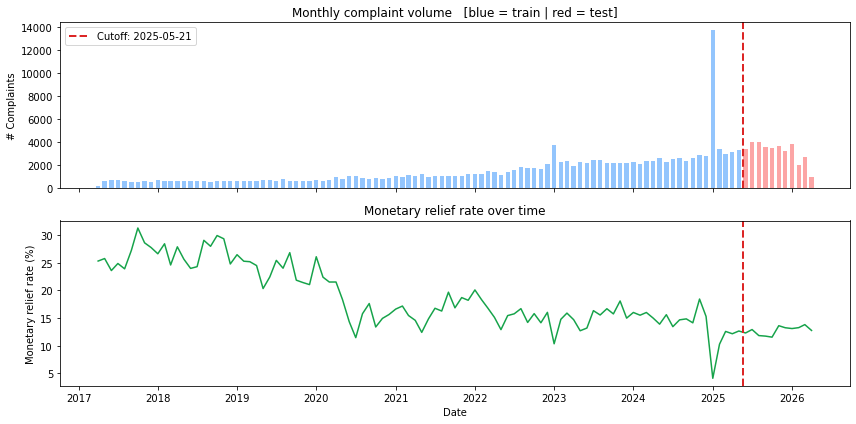

In [ ]:
monthly = df.groupby(df["date"].dt.to_period("M")).agg(
    total=("label", "count"), positive=("label", "sum")
).reset_index()
monthly["date_ts"] = monthly["date"].dt.to_timestamp()
monthly["pos_rate"] = monthly["positive"] / monthly["total"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].bar(monthly["date_ts"], monthly["total"], width=20,
            color=["#93c5fd" if t < cutoff_date else "#fca5a5"
                   for t in monthly["date_ts"]])
axes[0].axvline(cutoff_date, color="#dc2626", lw=2, linestyle="--",
                label=f"Cutoff: {cutoff_date.date()}")
axes[0].set_ylabel("# Complaints")
axes[0].set_title("Monthly complaint volume   [blue = train | red = test]")
axes[0].legend()

axes[1].plot(monthly["date_ts"], monthly["pos_rate"] * 100, color="#16a34a", lw=1.5)
axes[1].axvline(cutoff_date, color="#dc2626", lw=2, linestyle="--")
axes[1].set_ylabel("Monetary relief rate (%)")
axes[1].set_title("Monetary relief rate over time")
axes[1].set_xlabel("Date")

plt.tight_layout(); plt.show()

In [ ]:
X_train = train_df[FEATURES].values
X_test  = test_df[FEATURES].values
y_train = train_df["label"].values
y_test  = test_df["label"].values

qt = QuantileTransformer(output_distribution="uniform", random_state=42)
X_train_sc = qt.fit_transform(X_train)
X_test_sc  = qt.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_sc, y_train)

prob_train = model.predict_proba(X_train_sc)[:, 1]
prob_test  = model.predict_proba(X_test_sc)[:, 1]

fpr_tr, tpr_tr, _ = roc_curve(y_train, prob_train)
fpr_te, tpr_te, _ = roc_curve(y_test,  prob_test)
auc_tr = auc(fpr_tr, tpr_tr)
auc_te = auc(fpr_te, tpr_te)

print(f"In-sample  AUC: {auc_tr:.4f}")
print(f"Out-of-sample AUC: {auc_te:.4f}")
print(f"Gap:            {auc_tr - auc_te:+.4f}")
print()
print(classification_report(y_test, model.predict(X_test_sc),
                             target_names=["No relief", "Monetary relief"]))

In-sample  AUC: 0.6738
Out-of-sample AUC: 0.6149
Gap:            +0.0589

                 precision    recall  f1-score   support

      No relief       0.90      0.63      0.74     30982
Monetary relief       0.18      0.54      0.27      4486

       accuracy                           0.62     35468
      macro avg       0.54      0.59      0.50     35468
   weighted avg       0.81      0.62      0.68     35468



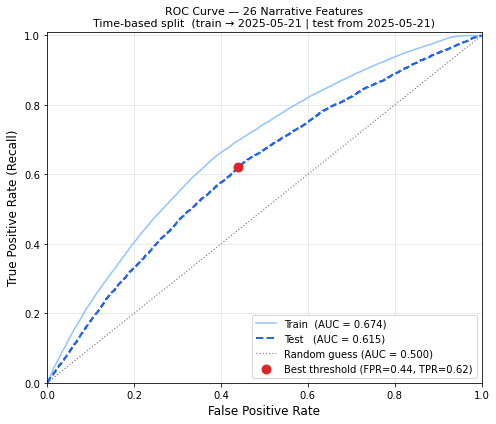

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_tr, tpr_tr, color="#93c5fd", lw=1.5, linestyle="-",
        label=f"Train  (AUC = {auc_tr:.3f})")
ax.plot(fpr_te, tpr_te, color="#2563eb", lw=2.0, linestyle="--",
        label=f"Test   (AUC = {auc_te:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1.2, linestyle=":",
        label="Random guess (AUC = 0.500)")

best_idx = np.argmin(np.sqrt(fpr_te**2 + (1 - tpr_te)**2))
ax.scatter(fpr_te[best_idx], tpr_te[best_idx], s=80, zorder=5, color="#dc2626",
           label=f"Best threshold (FPR={fpr_te[best_idx]:.2f}, TPR={tpr_te[best_idx]:.2f})")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title(f"ROC Curve — 26 Narrative Features\n"
             f"Time-based split  (train → {train_df['date'].max().date()} | "
             f"test from {test_df['date'].min().date()})", fontsize=11)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.01])
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

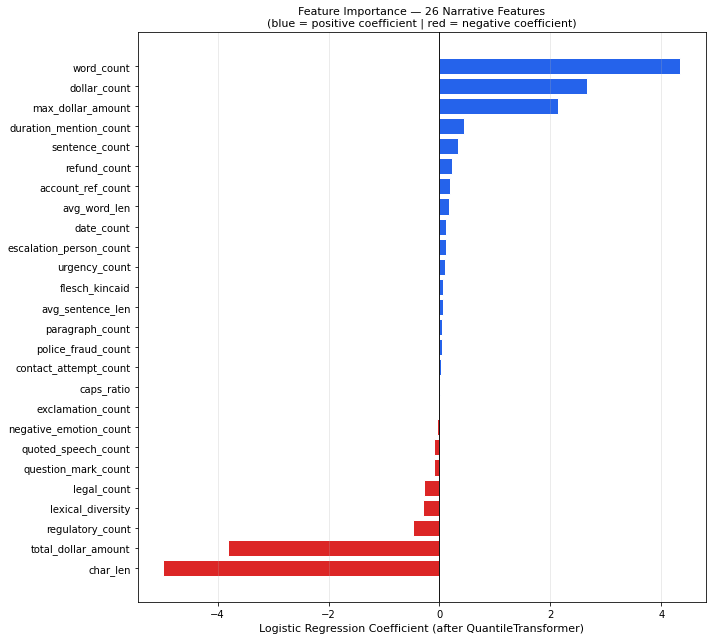

In [ ]:
coef_df = pd.DataFrame({
    "feature":     FEATURES,
    "coefficient": model.coef_[0],
}).sort_values("coefficient")

colors = ["#dc2626" if c < 0 else "#2563eb" for c in coef_df["coefficient"]]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.9)
ax.set_xlabel("Logistic Regression Coefficient (after QuantileTransformer)", fontsize=11)
ax.set_title("Feature Importance — 26 Narrative Features\n"
             "(blue = positive coefficient | red = negative coefficient)", fontsize=11)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()